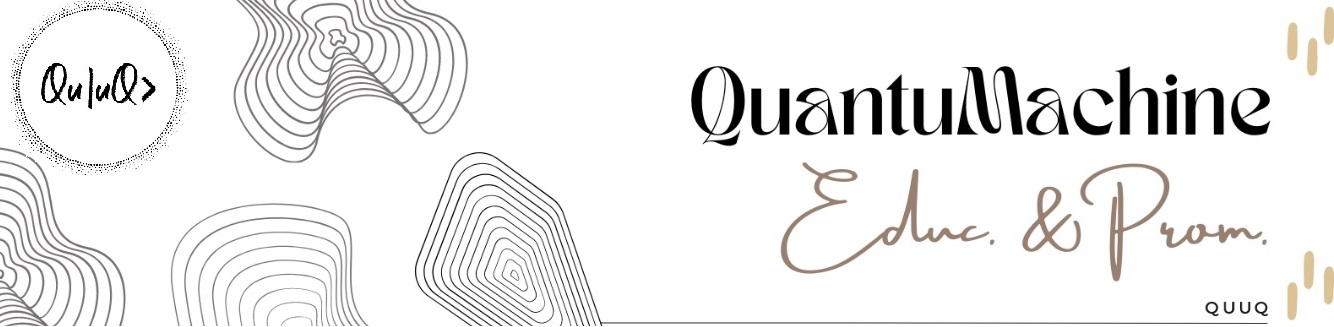

# **Library.**

In [1]:
'''
   Import qiskit libraries.'''
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.visualization import plot_circuit_layout, plot_state_city
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy
from qiskit.circuit.library import CCZGate, MCPhaseGate

'''
   Import ordinary libraries.'''
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, LinearLocator, FuncFormatter, LogLocator
from datetime import datetime


# Remarks
---
Part A is developed using a NumPy-based mathematical state-vector construction because this form directly represents the underlying linear-algebra description of the quantum token. In this stage, the basis states, tensor products, amplitudes, raw token state, and encoded token state can be inspected explicitly. This helps verify the mathematical correctness of the protocol before moving to a circuit-level implementation. 
   
Part B, after the state-vector formulation, the same protocol is then represented using a Qiskit model. This provides the corresponding quantum-circuit realization, which makes the protocol to visualize.
   
Therefore, the NumPy-based construction and the Qiskit model serve complementary purposes. The NumPy part explains what happens mathematically to the quantum state, while the Qiskit part shows how the same process can be implemented as a quantum circuit.


# Description
---

### 1. Initialization
The system starts from the 3-qubit initial state $|000\rangle$; therefore, the initial quantum state can be written as $|\psi_0\rangle = |000\rangle$.

### 2. Encoding operation
First, a Hadamard gate is applied to qubit $q_0$, which transforms $|0\rangle$ into superposition $H|0\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + |1\rangle\right)$. Since the other two qubits remain unchanged in the state $|0\rangle$, the total 3-qubit state becomes $|\psi_1\rangle = H_0 |000\rangle = \frac{1}{\sqrt{2}}\left(|000\rangle + |100\rangle\right)$. Next, the encoding unitary operation $U_k$ is applied. In this case, it consists of two CNOT gates: $U_k =\mathrm{CNOT}_{1,2}\mathrm{CNOT}_{0,2}$. The first CNOT gate has qubit $q_0$ as the control and qubit $q_2$ as the target, this leaves $|000\rangle$ unchanged, but flips the third qubit in $|100\rangle$, because the control qubit is $1$, thus, $\mathrm{CNOT}_{0,2}|000\rangle = |000\rangle$, and $\mathrm{CNOT}_{0,2}|100\rangle = |101\rangle$. Therefore, after applying $\mathrm{CNOT}_{0,2}$, the state becomes $\frac{1}{\sqrt{2}}\left(|000\rangle + |101\rangle\right)$. The second gate has qubit $q_1$ as the control and $q_2$ as the target. Since $q_1$ is $0$ in both basis states $|000\rangle$ and $|101\rangle$, this gate does not change the state. Therefore, the encoded quantum token state is 

$$|\psi_{\mathrm{encoded}}\rangle
= U_k |\psi_1\rangle = \frac{1}{\sqrt{2}}\left(|000\rangle + |101\rangle\right).$$

### 3. Decoding test
After this, the inverse unitary operation $U_k^\dagger$ is applied for decoding. Since each CNOT gate is self-inverse, the inverse operation is obtained by applying the same CNOT gates in reverse order: $U_k^\dagger = \mathrm{CNOT}_{0,2}\mathrm{CNOT}_{1,2}$. First, $\mathrm{CNOT}_{1,2}$ is applied. Again, because qubit $q_1$ is $0$ in both components of the encoded state, the state remains unchanged: $\mathrm{CNOT}_{1,2}\left[\frac{1}{\sqrt{2}}\left(|000\rangle + |101\rangle\right)\right] = \frac{1}{\sqrt{2}}\left(|000\rangle + |101\rangle\right)$. Then, $\mathrm{CNOT}_{0,2}$ is applied, as $\mathrm{CNOT}_{0,2}|000\rangle = |000\rangle$, and $\mathrm{CNOT}_{0,2}|101\rangle = |100\rangle$, the decoded state becomes

$$
|\psi_{\mathrm{decoded}}\rangle
= U_k^\dagger |\psi_{\mathrm{encoded}}\rangle
= \frac{1}{\sqrt{2}}\left(|000\rangle + |100\rangle\right).
$$

Finally, because the first qubit was prepared in the $X$-basis, a Hadamard gate is applied again to restore the state before measurement in the computational basis, this cab be expressed as $|\psi_{\mathrm{final}}\rangle = H_0 \left[\frac{1}{\sqrt{2}}\left(|000\rangle + |100\rangle\right)\right]$, which gives

$$
|\psi_{\mathrm{final}}\rangle=
\frac{1}{\sqrt{2}}
\left[
\frac{1}{\sqrt{2}}\left(|000\rangle + |100\rangle\right)
+
\frac{1}{\sqrt{2}}\left(|000\rangle - |100\rangle\right)
\right].
$$

Simplifying, it giives $|\psi_{\mathrm{final}}\rangle = |000\rangle$. Therefore, the complete state evolution is

$$
|000\rangle
\rightarrow
\frac{1}{\sqrt{2}}\left(|000\rangle + |100\rangle\right)
\rightarrow
\frac{1}{\sqrt{2}}\left(|000\rangle + |101\rangle\right)
\rightarrow
\frac{1}{\sqrt{2}}\left(|000\rangle + |100\rangle\right)
\rightarrow
|000\rangle.
$$

with $P(000)=1$,while all other measurement outcomes have probability zero.


# **Part A:**

# **@ STEP 1) Initialization**

In [2]:
'''
   Basis for qubit description and quantum gates for state manipulation.'''
zero = np.array([1, 0], dtype=complex);
one  = np.array([0, 1], dtype=complex);

print("=== Basis states ==="); print("|0> =", zero); print("|1> =", one); print("#"*40);

I = np.array([[1, 0], [0, 1]], dtype=complex); # Identity gate.
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex); # Hadamard gate.
print("\n=== Quantum gates used ==="); print("Identity gate (I):", I); print("\nHadamard gate (H):", H);


=== Basis states ===
|0> = [1.+0.j 0.+0.j]
|1> = [0.+0.j 1.+0.j]
########################################

=== Quantum gates used ===
Identity gate (I): [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Hadamard gate (H): [[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


# **@ STEP 2) Token preparation**

# (a) Qubit preparations

In [3]:
'''
   State manipulation of 'qubit 1 (designated for secret-answer purposes)', 
   i.e., q1 = U_bi|u_i> = H|0>, where U_bi = H is selected as the basis decided
   for qubit 1 to be considered during transactional measurement is X (= bi).
   
   If bi = Z (computational basis state 0 or 1) then q1 = I @ zero.'''
q1 = H @ zero; 
print("\nSecret-answer qubit q1:"); 
print(q1.reshape(2,1));

'''
   State of 'qubit 2 (designated for reference purposes)', i.e., q2 = |v_i> = |0>'''
q2 = zero; 
print("\nReference qubit q2:"); 
print(q2.reshape(2,1));

'''
   State of 'qubit 3 (designated as ancilla)', i.e., q3 = |c> = |0>'''
q3 = zero; 
print("\nAncilla qubit c:"); 
print(q3.reshape(2,1));



Secret-answer qubit q1:
[[0.70710678+0.j]
 [0.70710678+0.j]]

Reference qubit q2:
[[1.+0.j]
 [0.+0.j]]

Ancilla qubit c:
[[1.+0.j]
 [0.+0.j]]


# (b) Token preparation

In [4]:
'''
   Raw token state construction.'''
print("="*40); print("Raw token matrix:"); 
print("\n|phi_i> = (U_bi|u_i> ⊗ |v_i> ⊗ |c>) = (H|0> ⊗ |0> ⊗ |0>) = ");

raw_token = np.kron(np.kron(q1, q2), q3); # To form 3-qubit raw token state using tensor products: q1 ⊗ q2 ⊗ q3.
raw_token_matrix = raw_token.reshape(8,1); # To convert the 8-element state vector into an 8 x 1 column matrix.
print(raw_token_matrix);

'''
   Encoded token state construction.

   CNOT-based implementation of the encoding operation U_k performed, 
   which applied as a sequence of two controlled-NOT operations:
   
        U_k = CX(1,2) CX(0,2) = CX(secret-answer, ancilla) CX(reference, ancilla);

   where:
      index 0 corresponds to q1 (the secret-answer qubit), controls the first CNOT operation on q3 (the ancilla qubit).
      index 1 corresponds to q2 (the reference qubit), controls the second CNOT operation on q3 (the ancilla qubit).
      index 2 corresponds to q3 (the ancilla qubit), which acts as the common target for both CNOT operations.'''

print("="*40); print("Encoded token matrix:"); 
print("\n|psi_i> = U_k|phi_i> = U_k(U_bi|u_i> ⊗ |v_i> ⊗ |c>) = U_k(H|0> ⊗ |0> ⊗ |0>) = ");

def apply_cx(state, control, target, n_qubits=3): # To define a function that applies a CNOT gate.
    new_state = np.zeros_like(state); # To create an empty state vector with the same shape and type as the input state.

    for index, amplitude in enumerate(state): # For loop through each basis-state index and its corresponding amplitude.
        bits = list(format(index, f"0{n_qubits}b")); # To converts the basis-state index into its binary representation.
        
        if bits[control] == "1": # To check whether the control qubit is in state |1>.
            bits[target] = "0" if bits[target] == "1" else "1"; # To flip the target qubit.

        new_index = int("".join(bits), 2); # To convert the modified binary string back into a decimal index.
        new_state[new_index] += amplitude; # to move the amplitude from the old basis state to the new basis state.

    return new_state

encoded_token = apply_cx(raw_token, control=0, target=2); # To apply the first CNOT gate: control qubit = q1, target qubit = q3.
encoded_token = apply_cx(encoded_token, control=1, target=2); # To apply the second CNOT gate: control qubit = q2, target qubit = q3.

encoded_matrix = encoded_token.reshape(8,1); 
print(encoded_matrix);

print("\nEncoded token ket-wise amplitudes:");
basis_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]; # Ket-wise representation of encoded token.
for ket, amp in zip(basis_labels, encoded_matrix):
    print(f"{ket} : {amp[0]}");
    

Raw token matrix:

|phi_i> = (U_bi|u_i> ⊗ |v_i> ⊗ |c>) = (H|0> ⊗ |0> ⊗ |0>) = 
[[0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.        +0.j]]
Encoded token matrix:

|psi_i> = U_k|phi_i> = U_k(U_bi|u_i> ⊗ |v_i> ⊗ |c>) = U_k(H|0> ⊗ |0> ⊗ |0>) = 
[[0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]]

Encoded token ket-wise amplitudes:
|000> : (0.7071067811865475+0j)
|001> : 0j
|010> : 0j
|011> : 0j
|100> : 0j
|101> : (0.7071067811865475+0j)
|110> : 0j
|111> : 0j


# **Part II:**

# **Token: quanum circuit representation**

# (a) Token development (encoding)


=== Quantum circuit for token preparation ===

This circuit represents:

|psi_i> = U_k( |u_i>_{b_i} ⊗ |v_i> ⊗ |0>_c )

before token decoding and measurement.
     ┌───┐          
q_0: ┤ H ├──■───────
     ├───┤  │       
q_1: ┤ I ├──┼────■──
     ├───┤┌─┴─┐┌─┴─┐
q_2: ┤ I ├┤ X ├┤ X ├
     └───┘└───┘└───┘
c: 3/═══════════════
                    


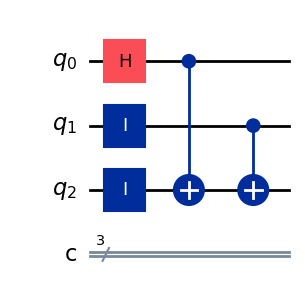

In [5]:
'''
   Quantum circuit construction, specifying the number of 
   quantum and classical registers (Step 1).'''
qc = QuantumCircuit(3, 3); # 3 qubits and 3 classical bits are allocated.

'''
   Quantum state preparation and token encoding process (Step 2).

   The required gates are applied to initialize the token qubits, then 
   encoding operation U_k is implemented.'''

qc.h(0); # Prepares q1 (the secret-answer qubit) in the X-basis state H|0>.
qc.id(1); # Keeps q2 (the reference qubit) unchanged in |0>.
qc.id(2); # Keeps q3 (the ancilla qubit) unchanged in |0>.

qc.cx(0, 2); # Applies CX(q1, q3): secret-answer qubit controls the ancilla.
qc.cx(1, 2); # Applies CX(q2, q3): reference qubit controls the ancilla.

'''
   Quantum token preparation circuit visualization (Step 3).

   The circuit represents the encoded quantum token before
   applying the decoding operation and before measurement.'''

print("\n=== Quantum circuit for token preparation ==="); 
print("\nThis circuit represents:\n");

print("|psi_i> = U_k( |u_i>_{b_i} ⊗ |v_i> ⊗ |0>_c )"); 
print("\nbefore token decoding and measurement.");

print(qc.draw(output="text")); # Circuit in text / ASCII format (below graphical circuit figure).
qc.draw(output="mpl")


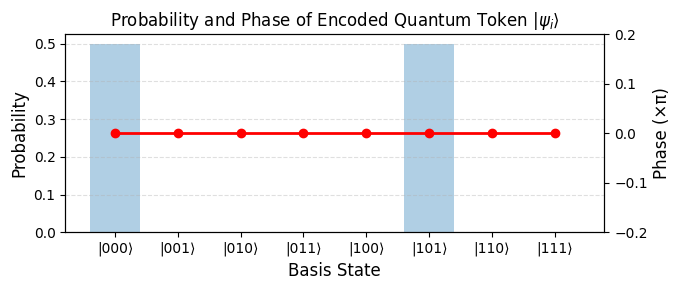

In [6]:
'''
   Simulation and visualization of the prepared token state (Step 4).

   The circuit prepared above represents the encoded quantum token before decoding and measurement.
   Since no measurement has been applied yet, the final statevector of the circuit can be extracted directly.'''
state = Statevector.from_instruction(qc); # To extract the final statevector from the prepared Qiskit circuit.
amps = state.data; # To store the complex amplitudes of all computational basis states.

'''
   Computational basis labels for the 3-qubit token state'''
basis = ["|000⟩", "|001⟩", "|010⟩", "|011⟩", "|100⟩", "|101⟩", "|110⟩", "|111⟩"];

'''
   Probability and phase extraction:
   P(x) = |amplitude(x)|²; phase(x) = arg(amplitude(x)) / π'''
probs = np.abs(amps) ** 2;
phases = np.angle(amps) / np.pi;

'''
   Plot probability distribution and phase profile'''
fig, ax1 = plt.subplots(figsize=(7, 3));

# Probability bar plot//
ax1.bar(basis, probs, alpha=0.35,);
ax1.set_ylabel("Probability", fontsize=12); 
ax1.set_ylim(0, 1.05 * max(probs));
ax1.set_xlabel("Basis State", fontsize=12);

# Phase line plot//
ax2 = ax1.twinx();
ax2.plot(basis, phases, marker="o", linewidth=2, color="red", label="Phase (×π)");
ax2.set_ylabel("Phase (×π)", fontsize=12);
ax2.set_ylim(min(phases) - 0.2, max(phases) + 0.2);

# Plot formatting
plt.title(r"Probability and Phase of Encoded Quantum Token $|\psi_i\rangle$", fontsize=12);

ax1.tick_params(axis="x", labelsize=10);
ax1.tick_params(axis="y", labelsize=10);
ax2.tick_params(axis="y", labelsize=10);

ax1.grid(True, axis="y", linestyle="--", alpha=0.4);

fig.tight_layout();
plt.show();


# (b) Token testing after development (decoding) : Several testing before giving to the customer (in actual)


=== Quantum circuit for token measurement ===
     ┌───┐           ░            ░ ┌───┐   ┌─┐
q_0: ┤ H ├──■────────░────────■───░─┤ H ├───┤M├
     ├───┤  │        ░        │   ░ └┬─┬┘   └╥┘
q_1: ┤ I ├──┼────■───░───■────┼───░──┤M├─────╫─
     ├───┤┌─┴─┐┌─┴─┐ ░ ┌─┴─┐┌─┴─┐ ░  └╥┘ ┌─┐ ║ 
q_2: ┤ I ├┤ X ├┤ X ├─░─┤ X ├┤ X ├─░───╫──┤M├─╫─
     └───┘└───┘└───┘ ░ └───┘└───┘ ░   ║  └╥┘ ║ 
c: 3/═════════════════════════════════╩═══╩══╩═
                                      1   2  0 


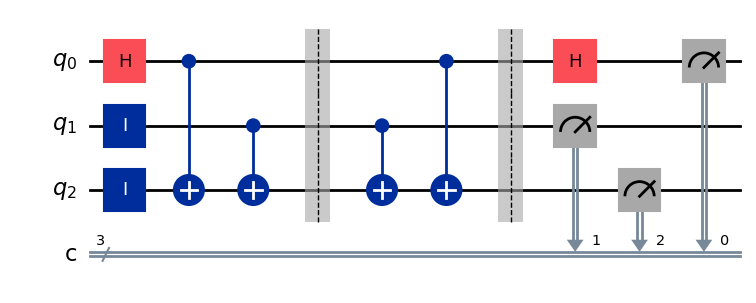

In [7]:
'''
   STEP 5: Decoding operation U_k.

   Since each CNOT gate is self-inverse, the same CNOT gates are reused.
   The decoding operation is applied in reverse order:
      first  : CX(q2, q3)
      second : CX(q1, q3).'''
qc.barrier(); # Separates the token-preparation stage from the decoding stage.

qc.cx(1, 2); # Applies CX(q2, q3) to undo the second encoding CNOT.
qc.cx(0, 2); # Applies CX(q1, q3) to undo the first encoding CNOT.

qc.barrier(); # Separates the decoding stage from basis restoration and measurement.


'''
   STEP 6: Basis restoration before measurement.

   As the qubit q1 was prepared in the X basis, another Hadamard gate was applied 
   before measurement to restore it to the computational basis: H(H|0>) = |0>'''
qc.h(0);

'''
   STEP 7: Measurement.

   Each qubit is measured into its corresponding classical bit.
      q1 -> classical bit 0
      q2 -> classical bit 1
      q3 -> classical bit 2'''
qc.measure(0, 0); # Measures q1, the secret-answer qubit.
qc.measure(1, 1); # Measures q2, the reference qubit.
qc.measure(2, 2); # Measures q3, the ancilla qubit.

print("\n=== Quantum circuit for token measurement ===");
print(qc.draw(output="text"));

# Optional graphical circuit//
qc.draw(output="mpl")


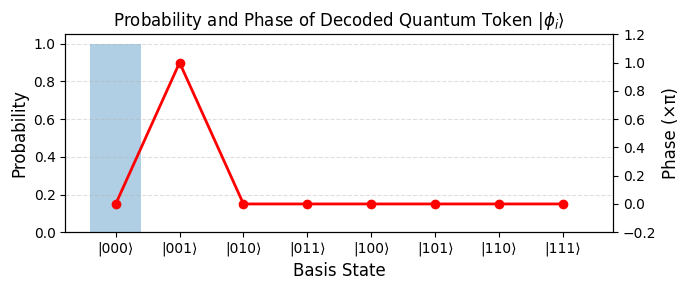

In [8]:
'''
   Simulation and visualization of the decoded token state.

   Statevector simulation cannot be applied directly to a circuit containing measurement operations. 
   Therefore, the final measurements are removed only for statevector analysis.'''
qc_decoded = qc.remove_final_measurements(inplace=False); # Creates a copy of the circuit without final measurement gates.

state = Statevector.from_instruction(qc_decoded); # To extract the decoded statevector.
amps = state.data; # To store the complex amplitudes of all computational basis states.

'''
   Computational basis labels for the 3-qubit decoded token state.'''
basis = ["|000⟩", "|001⟩", "|010⟩", "|011⟩", "|100⟩", "|101⟩", "|110⟩", "|111⟩"];

'''
   Probability and phase extraction:
   P(x) = |amplitude(x)|²; phase(x) = arg(amplitude(x)) / π.'''
probs = np.abs(amps) ** 2;
phases = np.angle(amps) / np.pi;

'''
   Plot probability distribution and phase profile.'''
fig, ax1 = plt.subplots(figsize=(7, 3));

# Probability bar plot//
ax1.bar(basis, probs, alpha=0.35);
ax1.set_ylabel("Probability", fontsize=12); 
ax1.set_ylim(0, 1.05 * max(probs));
ax1.set_xlabel("Basis State", fontsize=12);

# Phase line plot//
ax2 = ax1.twinx();
ax2.plot(basis, phases, marker="o", linewidth=2, color="red", label="Phase (×π)");
ax2.set_ylabel("Phase (×π)", fontsize=12);
ax2.set_ylim(min(phases) - 0.2, max(phases) + 0.2);

# Plot formatting//
plt.title(r"Probability and Phase of Decoded Quantum Token $|\phi_i\rangle$", fontsize=12);

ax1.tick_params(axis="x", labelsize=10);
ax1.tick_params(axis="y", labelsize=10);
ax2.tick_params(axis="y", labelsize=10);

ax1.grid(True, axis="y", linestyle="--", alpha=0.4);

fig.tight_layout();
plt.show();
